# PyTorch RNNs — Vanilla RNN to LSTM to Seq2Seq

Builds from a hand-rolled RNN cell through `nn.RNN`, `nn.LSTM`, `nn.GRU`, and a character-level language model.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
## 1. Vanilla RNN Cell — From Scratch

$$\mathbf{h}_t = \tanh(\mathbf{W}_h \mathbf{h}_{t-1} + \mathbf{W}_x \mathbf{x}_t + \mathbf{b})$$

We implement one step, then manually unroll across a sequence.

In [ ]:
class RNNCell(nn.Module):
    """Single RNN time step."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        # Combine Wx and Wh into one matrix for efficiency: [x, h] -> h
        self.linear = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        # x: (batch, input_size)   h_prev: (batch, hidden_size)
        combined = torch.cat([x, h_prev], dim=-1)  # (batch, input+hidden)
        return torch.tanh(self.linear(combined))  # (batch, hidden)


class VanillaRNN(nn.Module):
    """Unrolled RNN over a full sequence."""

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = RNNCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        # x: (batch, seq_len, input_size)
        batch, seq_len, _ = x.shape
        h = (
            h0
            if h0 is not None
            else torch.zeros(batch, self.hidden_size, device=x.device)
        )
        hidden_states = []
        for t in range(seq_len):
            h = self.cell(x[:, t, :], h)
            hidden_states.append(h)
        out = self.fc(h)  # use final hidden state for classification
        return out, torch.stack(hidden_states, dim=1)  # (batch, seq_len, hidden)


# Quick test
rnn = VanillaRNN(input_size=10, hidden_size=32, output_size=5)
x_test = torch.randn(4, 7, 10)  # batch=4, seq=7, features=10
logits, hiddens = rnn(x_test)
print(f"Output shape:  {logits.shape}")  # (4, 5)
print(f"Hiddens shape: {hiddens.shape}")  # (4, 7, 32)

Output shape:  torch.Size([4, 5])
Hiddens shape: torch.Size([4, 7, 32])


---
## 2. Vanishing Gradient Demonstration

Show empirically that gradients shrink exponentially with sequence length in a vanilla RNN.

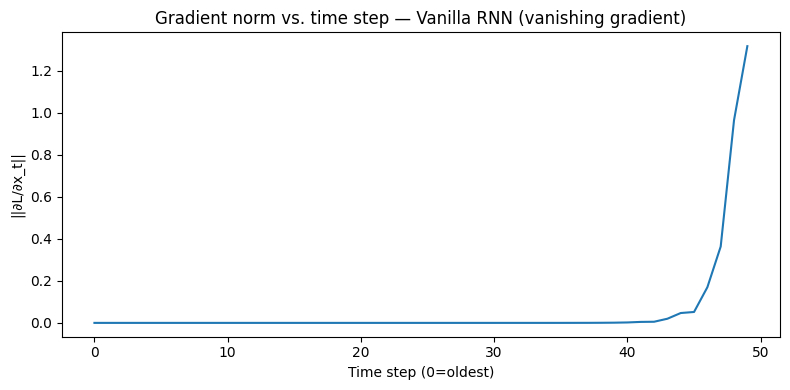

In [ ]:
def gradient_norm_by_step(model, seq_len, input_size, hidden_size):
    """Return L2 norm of gradient at each time step (step 0 = oldest)."""
    x = torch.randn(1, seq_len, input_size, requires_grad=True)
    h = torch.zeros(1, hidden_size)
    hidden_states = []
    for t in range(seq_len):
        h = model.cell(x[:, t, :], h)
        hidden_states.append(h)
    loss = hidden_states[-1].sum()  # gradient signal from last step
    loss.backward()
    # Gradient of loss w.r.t. each input time step
    grads = x.grad.norm(dim=-1).squeeze().tolist()
    return grads


rnn_test = VanillaRNN(10, 32, 1)
grads = gradient_norm_by_step(rnn_test, seq_len=50, input_size=10, hidden_size=32)

plt.figure(figsize=(8, 4))
plt.plot(grads)
plt.xlabel("Time step (0=oldest)")
plt.ylabel("||∂L/∂x_t||")
plt.title("Gradient norm vs. time step — Vanilla RNN (vanishing gradient)")
plt.tight_layout()
plt.show()

---
## 3. LSTM Cell — From Scratch

Explicit implementation of all four gates so the data flow is transparent.

$$\mathbf{f}_t = \sigma(\mathbf{W}_f [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f)$$
$$\mathbf{i}_t = \sigma(\mathbf{W}_i [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i)$$
$$\tilde{\mathbf{c}}_t = \tanh(\mathbf{W}_c [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c)$$
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t$$
$$\mathbf{o}_t = \sigma(\mathbf{W}_o [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o)$$
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)$$

In [ ]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Stack all four gate computations into one linear for efficiency
        # Output order: [forget | input | candidate | output]
        self.linear = nn.Linear(input_size + hidden_size, 4 * hidden_size)
        # Initialize forget gate bias to 1 to help remember at start of training
        nn.init.ones_(self.linear.bias[hidden_size : 2 * hidden_size])

    def forward(self, x, state):
        h_prev, c_prev = state  # both (batch, hidden)
        combined = torch.cat([x, h_prev], dim=-1)
        gates = self.linear(combined)  # (batch, 4*hidden)
        H = self.hidden_size
        f = torch.sigmoid(gates[:, 0 * H : 1 * H])  # forget
        i = torch.sigmoid(gates[:, 1 * H : 2 * H])  # input
        g = torch.tanh(gates[:, 2 * H : 3 * H])  # candidate cell
        o = torch.sigmoid(gates[:, 3 * H : 4 * H])  # output
        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c


class LSTMFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.cells = nn.ModuleList(
            [
                LSTMCell(input_size if l == 0 else hidden_size, hidden_size)
                for l in range(num_layers)
            ]
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, state=None):
        batch, seq_len, _ = x.shape
        if state is None:
            h = [torch.zeros(batch, self.hidden_size, device=x.device)] * len(
                self.cells
            )
            c = [torch.zeros(batch, self.hidden_size, device=x.device)] * len(
                self.cells
            )
        else:
            h, c = state

        all_hiddens = []
        for t in range(seq_len):
            inp = x[:, t, :]
            new_h, new_c = [], []
            for l, cell in enumerate(self.cells):
                inp, c_l = cell(inp, (h[l], c[l]))
                new_h.append(inp)
                new_c.append(c_l)
            h, c = new_h, new_c
            all_hiddens.append(h[-1])

        return self.fc(h[-1]), torch.stack(all_hiddens, dim=1)


lstm_scratch = LSTMFromScratch(10, 64, 5, num_layers=2)
out, hiddens = lstm_scratch(torch.randn(4, 20, 10))
print(f"LSTM output: {out.shape}, hiddens: {hiddens.shape}")

LSTM output: torch.Size([4, 5]), hiddens: torch.Size([4, 20, 64])


---
## 4. Using `nn.RNN`, `nn.LSTM`, `nn.GRU`

PyTorch's built-in modules are optimized (cuDNN kernels, fused operations) and should be used in practice.

In [ ]:
batch, seq, features, hidden = 8, 30, 16, 64
x = torch.randn(batch, seq, features)

# --- nn.RNN ---
rnn_module = nn.RNN(
    input_size=features, hidden_size=hidden, num_layers=2, batch_first=True, dropout=0.2
)
out_rnn, h_n_rnn = rnn_module(x)
print(f"RNN  out: {out_rnn.shape}  h_n: {h_n_rnn.shape}")
# out: (batch, seq, hidden)  h_n: (num_layers, batch, hidden)

# --- nn.LSTM ---
lstm_module = nn.LSTM(
    input_size=features, hidden_size=hidden, num_layers=2, batch_first=True, dropout=0.2
)
out_lstm, (h_n, c_n) = lstm_module(x)
print(f"LSTM out: {out_lstm.shape}  h_n: {h_n.shape}  c_n: {c_n.shape}")

# --- nn.GRU ---
gru_module = nn.GRU(
    input_size=features, hidden_size=hidden, num_layers=2, batch_first=True, dropout=0.2
)
out_gru, h_n_gru = gru_module(x)
print(f"GRU  out: {out_gru.shape}  h_n: {h_n_gru.shape}")

# --- Bidirectional LSTM ---
bi_lstm = nn.LSTM(
    input_size=features,
    hidden_size=hidden,
    num_layers=1,
    batch_first=True,
    bidirectional=True,
)
out_bi, _ = bi_lstm(x)
print(f"BiLSTM out: {out_bi.shape}")  # hidden_size * 2 because forward + backward

RNN  out: torch.Size([8, 30, 64])  h_n: torch.Size([2, 8, 64])
LSTM out: torch.Size([8, 30, 64])  h_n: torch.Size([2, 8, 64])  c_n: torch.Size([2, 8, 64])
GRU  out: torch.Size([8, 30, 64])  h_n: torch.Size([2, 8, 64])
BiLSTM out: torch.Size([8, 30, 128])


---
## 5. Character-Level Language Model

Train an LSTM to predict the next character in a text sequence. Classic proof-of-concept for RNNs.

In [ ]:
TEXT = (
    """
To be or not to be that is the question whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune or to take arms against a sea of troubles
and by opposing end them to die to sleep no more and by a sleep to say we end
the heartache and the thousand natural shocks that flesh is heir to tis a consummation
devoutly to be wished to die to sleep to sleep perchance to dream
"""
    * 20
)  # repeat to get enough data

chars = sorted(set(TEXT))
vocab_size = len(chars)
ch2idx = {c: i for i, c in enumerate(chars)}
idx2ch = {i: c for c, i in ch2idx.items()}
data = torch.tensor([ch2idx[c] for c in TEXT], dtype=torch.long)
print(f"Vocabulary: {vocab_size} characters  |  Data length: {len(data):,}")

Vocabulary: 26 characters  |  Data length: 7,980


In [ ]:
class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, i):
        x = self.data[i : i + self.seq_len]
        y = self.data[i + 1 : i + self.seq_len + 1]  # shifted by one
        return x, y


SEQ_LEN = 64
dataset = CharDataset(data, SEQ_LEN)
loader = DataLoader(dataset, batch_size=128, shuffle=True)
print(f"Batches per epoch: {len(loader)}")

Batches per epoch: 62


In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            embed_dim, hidden_size, num_layers, batch_first=True, dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, state=None):
        emb = self.drop(self.embed(x))  # (batch, seq, embed)
        out, state = self.lstm(emb, state)  # (batch, seq, hidden)
        logits = self.fc(self.drop(out))  # (batch, seq, vocab)
        return logits, state

    def init_state(self, batch_size):
        h = torch.zeros(
            self.lstm.num_layers, batch_size, self.lstm.hidden_size, device=device
        )
        c = torch.zeros_like(h)
        return h, c


char_model = CharLSTM(vocab_size, embed_dim=64, hidden_size=256, num_layers=2).to(
    device
)
print(f"Parameters: {sum(p.numel() for p in char_model.parameters()):,}")

Parameters: 864,410


In [ ]:
optimizer = optim.Adam(char_model.parameters(), lr=3e-3)
criterion = nn.CrossEntropyLoss()
losses = []

for epoch in range(30):
    char_model.train()
    epoch_loss = 0
    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        optimizer.zero_grad()
        logits, _ = char_model(X)
        # logits: (batch, seq, vocab) -> reshape for CrossEntropy
        loss = criterion(logits.view(-1, vocab_size), Y.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(char_model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        ppl = math.exp(avg_loss)  # perplexity = exp(cross-entropy loss)
        print(f"Epoch {epoch+1:2d} | loss {avg_loss:.4f} | perplexity {ppl:.1f}")

Epoch 10 | loss 0.0586 | perplexity 1.1
Epoch 20 | loss 0.0548 | perplexity 1.1
Epoch 30 | loss 0.0540 | perplexity 1.1


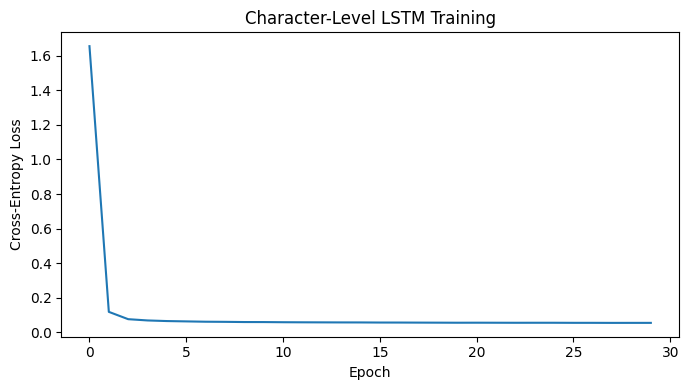

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Character-Level LSTM Training")
plt.tight_layout()
plt.show()

In [ ]:
def generate(model, seed, length=200, temperature=0.8):
    """
    Temperature controls sharpness of the distribution:
      T < 1: more deterministic (picks high-prob chars)
      T > 1: more random
    """
    model.eval()
    chars_out = list(seed)
    x = torch.tensor([[ch2idx[c] for c in seed]], dtype=torch.long, device=device)
    state = model.init_state(1)
    with torch.no_grad():
        # Prime the state with the seed
        _, state = model(x, state)
        # Generate one character at a time
        x_next = x[:, -1:]
        for _ in range(length):
            logits, state = model(x_next, state)
            probs = F.softmax(logits[0, 0] / temperature, dim=0)
            next_idx = torch.multinomial(probs, 1).item()
            chars_out.append(idx2ch[next_idx])
            x_next = torch.tensor([[next_idx]], device=device)
    return "".join(chars_out)


print(generate(char_model, seed="to be or not", length=300, temperature=0.7))

to be or not to be that is the question whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune or to take arms against a sea of troubles
and by opposing end them to die to sleep no more and by a sleep to say we end
the heartache and the thousand natural shocks that flesh is heir to


---
## 6. Sequence Classification with LSTM

Classify sequences — here we use a synthetic task: predict if the sum of a sequence of integers is above the median.

RNN  final val acc: 0.9750
LSTM final val acc: 0.9860
GRU  final val acc: 0.9840


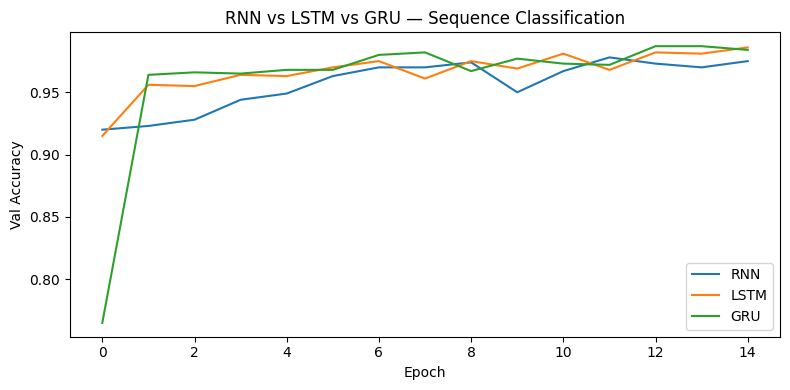

In [ ]:
# Synthetic: classify whether mean(x) > 0
N, SEQ, FEAT = 5000, 20, 1
X_cls = torch.randn(N, SEQ, FEAT)
y_cls = (X_cls.mean(dim=1).squeeze() > 0).long()  # binary: mean positive or not

idx = torch.randperm(N)
X_tr, y_tr = X_cls[idx[:4000]], y_cls[idx[:4000]]
X_vl, y_vl = X_cls[idx[4000:]], y_cls[idx[4000:]]

train_dl = DataLoader(list(zip(X_tr, y_tr)), batch_size=64, shuffle=True)
val_dl = DataLoader(list(zip(X_vl, y_vl)), batch_size=128)


class SequenceClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, n_classes, cell="lstm"):
        super().__init__()
        if cell == "lstm":
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        elif cell == "gru":
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])  # last hidden state


results_cells = {}
for cell_type in ["rnn", "lstm", "gru"]:
    clf = SequenceClassifier(FEAT, 32, 2, cell=cell_type).to(device)
    opt = optim.Adam(clf.parameters(), lr=1e-3)
    val_accs = []
    for epoch in range(15):
        clf.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(clf(xb), yb)
            loss.backward()
            opt.step()
        clf.eval()
        with torch.no_grad():
            preds = clf(X_vl.to(device)).argmax(1).cpu()
            val_accs.append((preds == y_vl).float().mean().item())
    results_cells[cell_type] = val_accs
    print(f"{cell_type.upper():4s} final val acc: {val_accs[-1]:.4f}")

plt.figure(figsize=(8, 4))
for cell_type, accs in results_cells.items():
    plt.plot(accs, label=cell_type.upper())
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("RNN vs LSTM vs GRU — Sequence Classification")
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Attention over RNN Hidden States

Bahdanau-style additive attention on top of a bidirectional LSTM — the precursor to transformers.

Attention model val acc: 0.9840


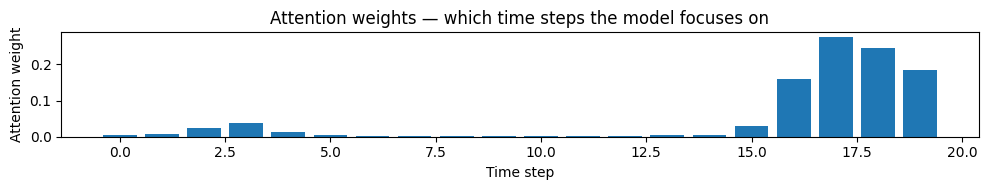

In [ ]:
class BahdanauAttention(nn.Module):
    """Additive attention: score = v^T tanh(W1*h_enc + W2*h_dec)"""

    def __init__(self, enc_hidden, dec_hidden):
        super().__init__()
        self.W1 = nn.Linear(enc_hidden, dec_hidden, bias=False)
        self.W2 = nn.Linear(dec_hidden, dec_hidden, bias=False)
        self.v = nn.Linear(dec_hidden, 1, bias=False)

    def forward(self, encoder_outputs, decoder_hidden):
        # encoder_outputs: (batch, src_len, enc_hidden)
        # decoder_hidden:  (batch, dec_hidden)
        query = self.W2(decoder_hidden).unsqueeze(1)  # (batch, 1, dec_hidden)
        keys = self.W1(encoder_outputs)  # (batch, src_len, dec_hidden)
        scores = self.v(torch.tanh(keys + query))  # (batch, src_len, 1)
        weights = F.softmax(scores, dim=1)  # (batch, src_len, 1)
        context = (weights * encoder_outputs).sum(1)  # (batch, enc_hidden)
        return context, weights.squeeze(-1)


class AttentionClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, n_classes):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size, hidden_size, batch_first=True, bidirectional=True
        )
        self.attention = BahdanauAttention(hidden_size * 2, hidden_size)
        self.query_vec = nn.Parameter(
            torch.randn(hidden_size)
        )  # learnable global query
        self.fc = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        enc_out, _ = self.bilstm(x)  # (batch, seq, 2*hidden)
        q = self.query_vec.unsqueeze(0).expand(x.size(0), -1)  # (batch, hidden)
        context, attn_weights = self.attention(enc_out, q)  # (batch, 2*hidden)
        return self.fc(context), attn_weights


attn_model = AttentionClassifier(FEAT, 32, 2).to(device)
opt = optim.Adam(attn_model.parameters(), lr=1e-3)
for epoch in range(15):
    attn_model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits, _ = attn_model(xb)
        F.cross_entropy(logits, yb).backward()
        opt.step()
attn_model.eval()
with torch.no_grad():
    preds, attn = attn_model(X_vl.to(device))
    acc = (preds.argmax(1).cpu() == y_vl).float().mean()
print(f"Attention model val acc: {acc:.4f}")

# Visualize attention for a single example
plt.figure(figsize=(10, 2))
plt.bar(range(SEQ), attn[0].cpu().detach())
plt.xlabel("Time step")
plt.ylabel("Attention weight")
plt.title("Attention weights — which time steps the model focuses on")
plt.tight_layout()
plt.show()

---
## 8. Gradient Clipping — Why It Matters

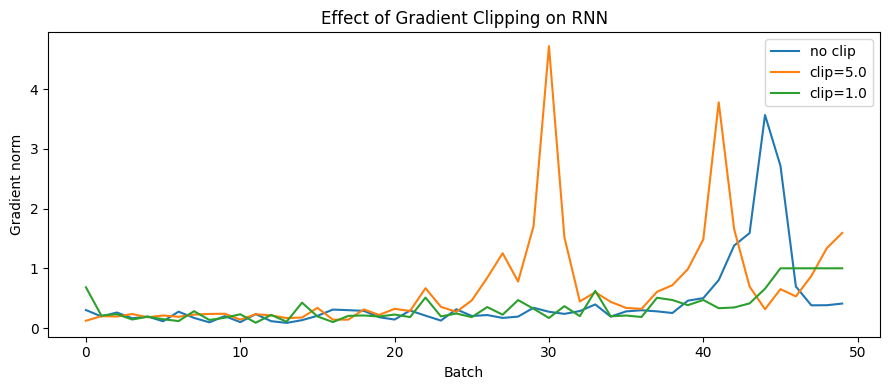

In [ ]:
def train_with_clip(clip_val):
    model = SequenceClassifier(FEAT, 64, 2, cell="rnn").to(device)
    opt = optim.SGD(model.parameters(), lr=0.1)
    losses = []
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        if clip_val is not None:
            nn.utils.clip_grad_norm_(model.parameters(), clip_val)
        total_norm = (
            sum(p.grad.norm() ** 2 for p in model.parameters() if p.grad is not None)
            ** 0.5
        )
        opt.step()
        losses.append(total_norm.item())
        if len(losses) >= 50:
            break
    return losses


plt.figure(figsize=(9, 4))
for clip in [None, 5.0, 1.0]:
    label = f"clip={clip}" if clip else "no clip"
    plt.plot(train_with_clip(clip), label=label)
plt.xlabel("Batch")
plt.ylabel("Gradient norm")
plt.title("Effect of Gradient Clipping on RNN")
plt.legend()
plt.tight_layout()
plt.show()